## Default Risk Prediction

A South African car dealership, aims to predict which customers are likely to default on their car installments within the next 12 months. The goal is to reduce financial risk by identifying high-risk individuals early.

### Objectives
- Predict the likelihood of default on car installment payments.
- Address data issues like multicollinearity and outliers.

# Data loading

In [1]:
import numpy as np
import pandas as pd

In [2]:
customers = pd.read_csv('customers_loan_data.csv')

In [3]:
customers.head(10)

,Cust_ID,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
0,1,0,26326.80829,336163.9392,19,21.198108,1,21
1,2,0,25854.14465,327907.1687,51,20.291501,0,31
2,3,0,27467.56013,307316.5774,27,23.188395,1,22
3,4,0,26523.13227,327149.2029,18,21.325711,1,40
4,5,0,27642.66993,318970.9595,47,16.695411,0,34
5,6,0,24138.70235,317211.9257,32,15.433123,1,38
6,7,0,25066.24017,332517.2322,16,17.534248,1,31
7,8,0,26526.73615,332395.5473,42,17.998367,1,18
8,9,0,26677.60059,324001.4019,42,16.430430,1,52
9,10,0,25405.63762,327784.7453,12,15.942525,1,32


# Exploring the data(EDA)

In [4]:
#Drop unnecessary ID columns
customers.drop(columns=['Cust_ID'], inplace= True)
customers.shape

(15000, 7)

In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Default        15000 non-null  int64  
 1   Salary         15000 non-null  float64
 2   Balance        15000 non-null  float64
 3   Age            15000 non-null  int64  
 4   Interest_Rate  15000 non-null  float64
 5   Insurance      15000 non-null  int64  
 6   Term_Left      15000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 820.4 KB


In [6]:
customers.describe()

,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.300000,25995.895663,330006.468744,31.302733,17.990015,0.807267,27.806267
std,0.458273,1494.401668,9911.062022,19.881180,2.991916,0.394459,9.424174
min,0.000000,20096.012110,290682.647800,-50.000000,7.531051,0.000000,0.000000
25%,0.000000,24990.132812,323358.522750,18.000000,15.979962,1.000000,21.000000
50%,0.000000,25970.865375,329960.732800,31.000000,17.985703,1.000000,28.000000
75%,1.000000,26982.612092,336668.245975,45.000000,20.019393,1.000000,34.000000
max,1.000000,32726.315920,374666.489400,125.000000,29.170477,1.000000,63.000000


**Things to note:**  
*Age*
> The min age is negative(this is an error)
> On the 75th quantile the age is 45 but then jumps to 125 years(max), this is an indication of outliers.

*Insuarance*
> It seems like majority of the people have insuarence, since on the 25th till max we have '1'

In [7]:
negative_ages = customers[customers.Age < 0]
negative_ages.head()

,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
33,0,25213.80579,333604.1615,-7,13.381587,1,19
37,0,27912.27628,352335.2920,-4,24.358981,1,46
47,0,26670.66940,336081.9145,-12,17.679509,1,24
64,0,26425.38301,343465.0744,-38,21.762367,1,31
100,0,26731.35411,329007.8474,-21,17.107835,1,16


In [8]:
print('Number of records with negative ages:',len(negative_ages))
print('Percentage of negative age records  : %0.2f%%' % (len(negative_ages)/len(customers)*100))

Number of records with negative ages: 826
Percentage of negative age records  : 5.51%


**5.51%** may not look like much but that's 826 records with some valuable information. In this case, I will chose to take the absolute value of the age.

In [9]:
#Make the ages positive
customers.loc[negative_ages.index,'Age'] = abs(negative_ages['Age'])
#Display the ages that have been made positive
customers.iloc[negative_ages.index]

,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
33,0,25213.80579,333604.1615,7,13.381587,1,19
37,0,27912.27628,352335.2920,4,24.358981,1,46
47,0,26670.66940,336081.9145,12,17.679509,1,24
64,0,26425.38301,343465.0744,38,21.762367,1,31
100,0,26731.35411,329007.8474,21,17.107835,1,16
...,...,...,...,...,...,...,...
14946,1,26378.37940,327508.2328,24,15.881383,1,32
14961,1,24498.38105,342952.8738,6,17.907615,0,30
14966,1,28316.43368,332276.7808,16,20.573270,1,18
14969,1,27229.51643,339234.0312,1,21.465494,0,31


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

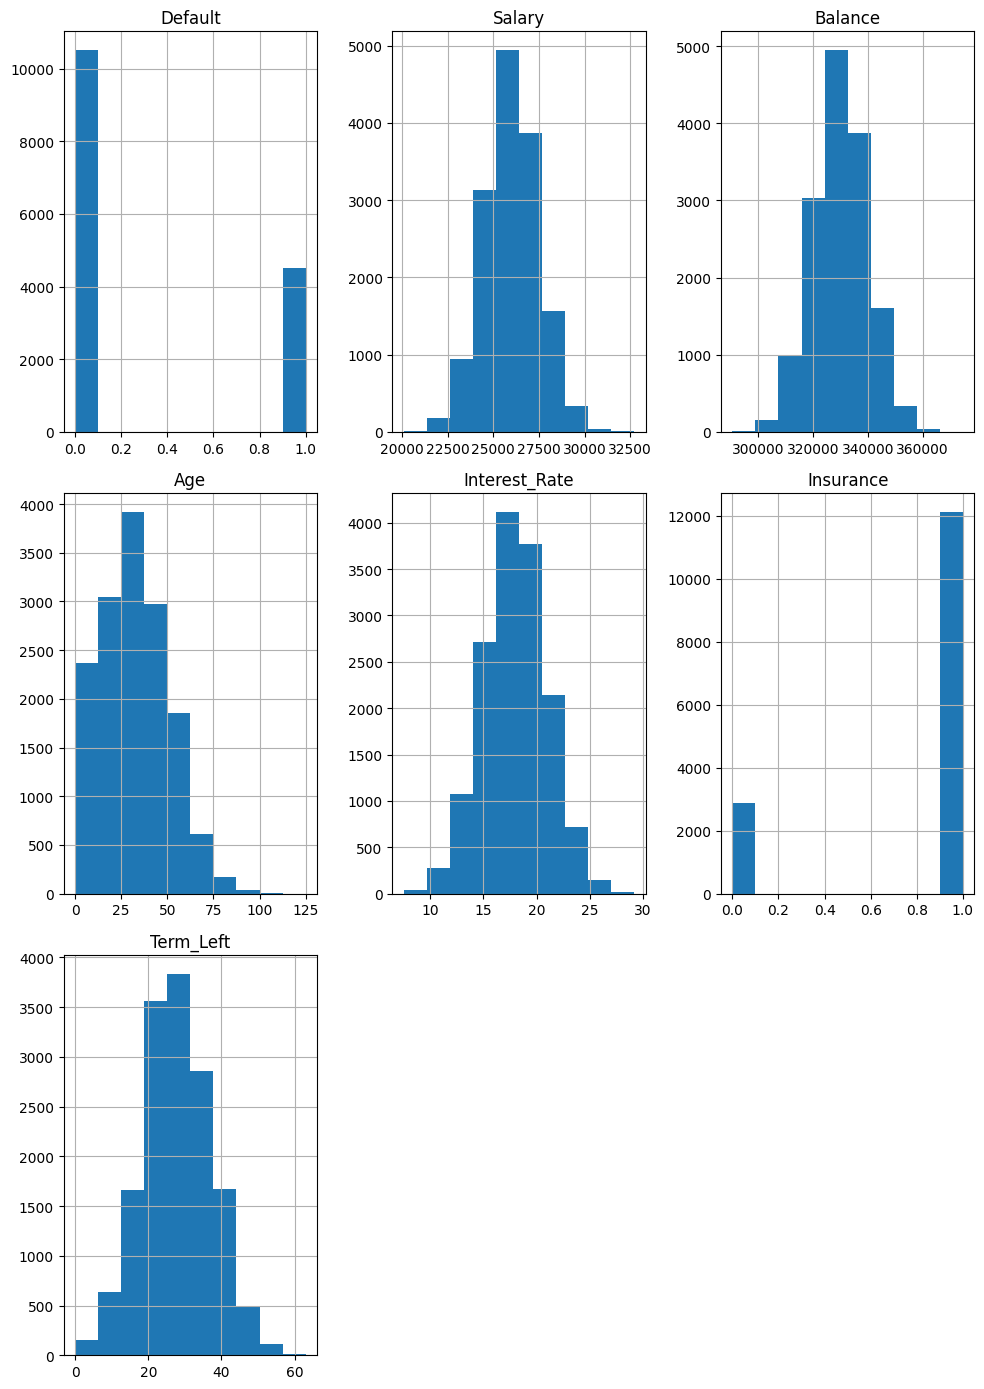

In [11]:
customers.hist(figsize=(10,14))
plt.tight_layout()
plt.show()

From the histograms above, the data looks like it's normally distributed for most features. Except for the `Age` feature, this is likey due to some outliers.

Default
0    10500
1     4500
Name: count, dtype: int64


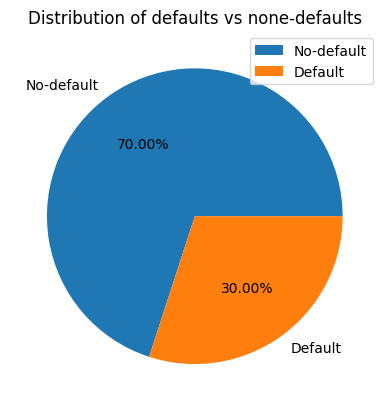

In [12]:
print(customers['Default'].value_counts())
customers['Default'].value_counts().plot.pie(autopct='%0.2f%%',labels=['No-default','Default'] )
plt.title('Distribution of defaults vs none-defaults')
plt.legend()
plt.ylabel('')
plt.show()

In terms of the `Default` column, the data as it is is not balanced. Depending on the outcomes of the models, we might need to undersample the data so that we have almost the same number of *Defaults* and *Non-defaults*.

# Handling inconsistencies

Since we're looking at loaning data. It is assumed that the records should be of individuals of at least 18 years old with age limit of 65 in most cases. But since a person can take a loan at age 64 that spans over a few years, we will leave out those records with `Age > 65`.

In [13]:
illegal_ages = customers[(customers.Age < 18) | (customers.Age > 65)]
print('Number of records with illegal ages: ', len(illegal_ages))
print('Percentage of illegal age records  : %0.2f%%' % (len(illegal_ages)/len(customers)*100),'\n')
illegal_ages.head()

Number of records with illegal ages:  4145
Percentage of illegal age records  : 27.63% 



,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
6,0,25066.24017,332517.2322,16,17.534248,1,31
9,0,25405.63762,327784.7453,12,15.942525,1,32
11,0,25521.79749,343940.8312,13,20.603942,1,22
13,0,27440.47352,345830.0809,10,17.773182,1,35
14,0,26535.49150,338579.8120,80,20.557466,1,39


In [14]:
illegal_ages['Default'].value_counts()

Default
0    2697
1    1448
Name: count, dtype: int64

In [15]:
#remove all the records where the age is less than 18 years
customers_filtered = customers.drop(index=illegal_ages.index)
customers_filtered.head()

,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
0,0,26326.80829,336163.9392,19,21.198108,1,21
1,0,25854.14465,327907.1687,51,20.291501,0,31
2,0,27467.56013,307316.5774,27,23.188395,1,22
3,0,26523.13227,327149.2029,18,21.325711,1,40
4,0,27642.66993,318970.9595,47,16.695411,0,34


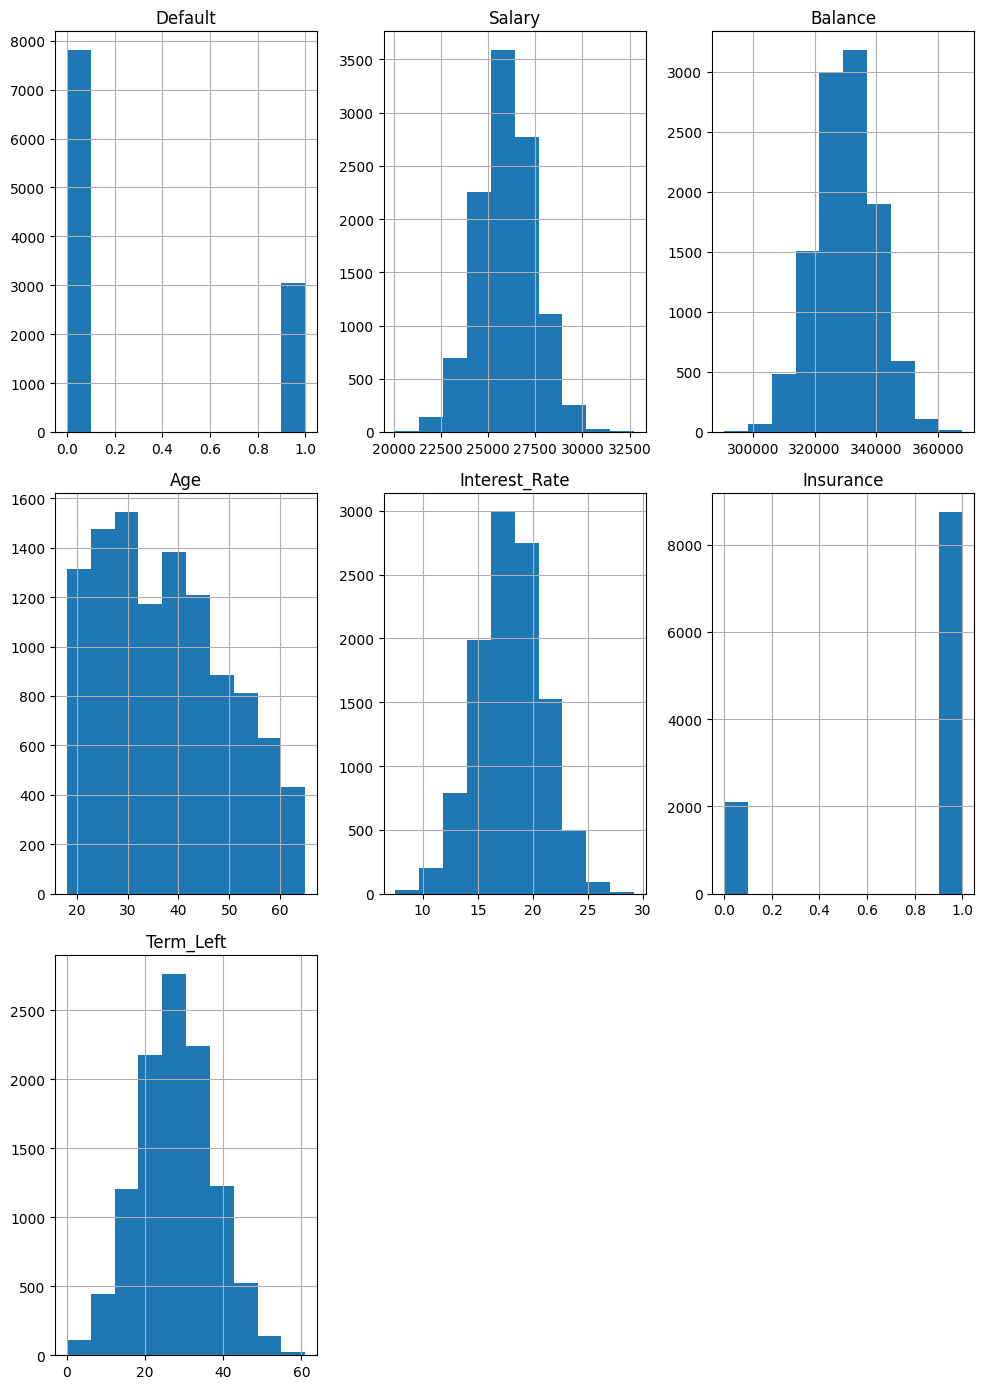

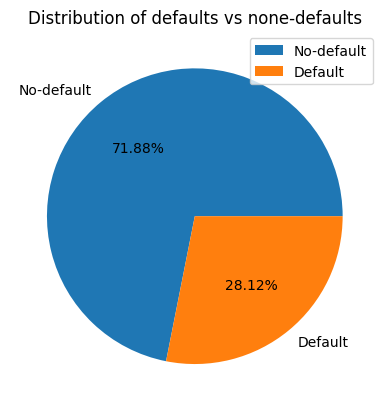

In [16]:
#Replot the data
customers_filtered.hist(figsize=(10,14))
plt.tight_layout()
plt.show()

#Replot the pie chart
customers_filtered['Default'].value_counts().plot.pie(autopct='%0.2f%%',labels=['No-default','Default'] )
plt.title('Distribution of defaults vs none-defaults')
plt.legend()
plt.ylabel('')
plt.show()

In [17]:
no_terms_left = customers_filtered.nsmallest(columns='Term_Left',n=10)
no_terms_left

,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
843,0,23389.01243,323353.7819,43,24.593368,1,0
1778,0,26073.83495,320672.9706,28,18.066535,1,0
3000,0,27307.20404,332217.7149,24,22.068346,1,0
8205,0,24251.57709,308369.3151,35,22.693029,1,0
9779,0,25742.91724,340933.1605,22,14.695630,1,0
12138,1,27477.84164,340213.7930,54,23.624320,0,0
192,0,29923.15253,325124.7869,49,20.980144,1,1
988,0,25988.34757,330189.7435,32,20.727585,1,1
2110,0,22898.54726,339654.7690,55,16.894626,1,1
2540,0,26216.48009,325357.4338,25,16.521577,1,1


It's also strange that there are individuals who have *0* terms left but still have a huge balance left despite having an insuarance. In this case, we can remove such records since it does not make sense. The ones with a **1** term left are more likey to default since, as we can observe, their remaining `Balance` is almost as larger than their current `Salary`

In [18]:
customers_filtered = customers_filtered.drop(index=no_terms_left.head(6).index)
customers_filtered.nsmallest(columns='Term_Left',n=10)

,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
192,0,29923.15253,325124.7869,49,20.980144,1,1
988,0,25988.34757,330189.7435,32,20.727585,1,1
2110,0,22898.54726,339654.7690,55,16.894626,1,1
2540,0,26216.48009,325357.4338,25,16.521577,1,1
3843,0,25932.96201,307459.5186,51,17.429389,1,1
4671,0,26999.15689,337854.6389,28,21.275357,1,1
5847,0,27133.16234,312761.9764,52,17.993894,1,1
6977,0,23813.26776,327797.6958,35,20.744371,1,1
7400,0,23962.57350,332417.3150,31,14.711150,1,1
7541,0,25935.69476,327519.2296,52,14.286180,1,1


In [19]:
customers_filtered.value_counts('Default')

Default
0    7798
1    3051
Name: count, dtype: int64

# Model trainning

In [20]:
from sklearn.preprocessing import StandardScaler

# Scale the data
cols_to_scale = customers_filtered.drop(columns=['Insurance','Default']).columns
customers_filtered[cols_to_scale] = StandardScaler().fit_transform(customers_filtered[cols_to_scale])
customers_filtered

,Default,Salary,Balance,Age,Interest_Rate,Insurance,Term_Left
0,0,0.224994,0.625611,-1.502883,1.095139,1,-0.727889
1,0,-0.089144,-0.214605,1.105073,0.790077,0,0.338348
2,0,0.983152,-2.309922,-0.850894,1.764846,1,-0.621266
3,0,0.355474,-0.291736,-1.584381,1.138076,1,1.297961
4,0,1.099532,-1.123962,0.779078,-0.419962,0,0.658219
...,...,...,...,...,...,...,...
14988,1,0.078465,0.045003,0.779078,1.089991,0,1.511208
14989,1,0.143883,-1.276177,-0.932392,0.013916,1,1.831079
14991,1,0.280328,-0.466960,-0.524899,-0.300467,0,0.018477
14993,1,-0.718433,-0.093030,-0.117406,-0.458282,0,-0.621266


Since the data is not balanced, we will do some sampling of the data using the `SMOTE(oversampling the minority)`

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = customers_filtered.drop(columns='Default')
y = customers_filtered['Default']

print('Shape of data(X,y)              :', X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
print('Shape of testing(X,y)           :', X_train.shape, y_train.shape)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print('Shape of sampled_training(X,y)  :',X_resampled.shape, y_resampled.shape)

Shape of data(X,y)              : (10849, 6) (10849,)
Shape of testing(X,y)           : (8136, 6) (8136,)
Shape of sampled_training(X,y)  : (11696, 6) (11696,)


In [22]:
# Split data into training and testing
from sklearn.model_selection import train_test_split
X_train, y_train = X_resampled, y_resampled

X_train.shape, y_train.shape

((11696, 6), (11696,))

The training process will use **KFold-cross-validate**. It will also include a learning curve where we look at the number of samples with the `accuracy score` of each sample size.

**The following models will be trained:**
- *Suport Vector machines(Linear and SVC)*
- *XBBoost*
- *Navive Bayes (Gaussian)*
- Logistic Regression
- Random Forest

<br>

The model choice will be based on the `LeaningCurve` as well as the `Acuracy` score and `F1` score

In [23]:
#Import library
#- Validation
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import LearningCurveDisplay


# Train multiple models that can handle normally distributed data very well
from sklearn import svm
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

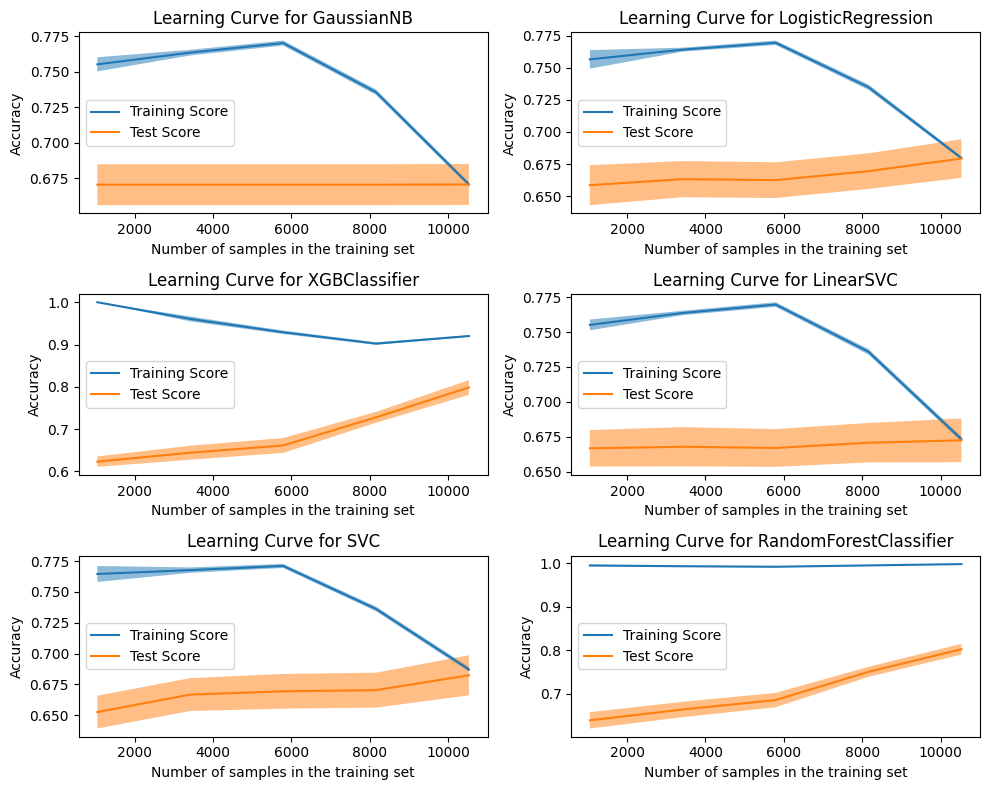

In [24]:
#Configure the KFold class
kfold = KFold(random_state=1000,shuffle=True,n_splits=10)

#Create sub plots for the learning curves
fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(10,8), sharey=False)

#Dictionary that will hold the resutls
# - The results will be the averge score of the f1 and the accuracy
results = []

#Create the models
models = [GaussianNB(),
          LogisticRegression(max_iter=5000),
          xgb.XGBClassifier(eval_metric='logloss'),
          svm.LinearSVC(),
          svm.SVC(gamma='auto'),
          RandomForestClassifier(n_estimators=20, random_state=42)]

#For the learning curves
common_params = {
    "X": X_train,
    "y": y_train,
    "cv": kfold,
    "score_type": "both",
    "n_jobs": -1,
    "score_name": "Accuracy"}

for index, model in enumerate(models):
    col = index % 2
    row = index // 2
    #Do a cross validation
    #-- This will be for evaluating the model perfomance
    cv = cross_validate(model, cv=kfold, X=X_train, y=y_train, scoring=['accuracy','f1'])
    
    LearningCurveDisplay.from_estimator(model,**common_params, ax=ax[row,col])
    
    handles, label = ax[row,col].get_legend_handles_labels()
    ax[row,col].legend(handles[:2], ["Training Score", "Test Score"])
    ax[row,col].set_title(f"Learning Curve for {model.__class__.__name__}")

    #Capture the scores from the cross validation
    results.append({'Model': model.__class__.__name__, 'Accuracy': cv['test_accuracy'].mean(),'F1':cv['test_f1'].mean()})

plt.tight_layout()
plt.show()

In [25]:
pd.DataFrame(results)

,Model,Accuracy,F1
0,GaussianNB,0.670656,0.572600
1,LogisticRegression,0.679292,0.624863
2,XGBClassifier,0.801128,0.792078
3,LinearSVC,0.672366,0.604274
4,SVC,0.682454,0.619584
5,RandomForestClassifier,0.803267,0.797539


# Model choice and evaluation
From the data we have above, it seems like the `RandomForestClassifier` has both the highest **Accuracy** as well as **F1** scores.  

But when looking at the learning curves, the accuracy of the training score is always a **100%** but when looking at the one for test score, the accuracy starts from **< 70%** and gradually grows to **+80%**. This alone does indicate that the model has a very *high Variance* and is sensitive to the sample size. This can also suggest that `RandomForestClassifier` may not be an appropriate model for this scenario since it's overfitting the testing data and does bad when testing.  

  
And for that reason, we will take the second highest on the table which is the **XGBClassifier** with a good accuracy and f1 score.

In [26]:
#Model evaluation 
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [27]:
# Train the XGBClassifier
model = xgb.XGBClassifier(eval_metric='logloss')
model.fit(X_resampled, y_resampled)

#Predict the values using the testing set
predictions = model.predict(X_test)
print('Accuracy: %0.2f%%' % (metrics.accuracy_score(predictions, y_test) * 100))

Accuracy: 72.47%


In [28]:
cm = confusion_matrix(y_test, predictions)
print('Confusion matrix:')
print('\t\t\tPredictions\n')
print('\t\tDefault(1) \tNo-Default(0)')
print('Default(1)\t', cm[1,1],'(TP)','\t',cm[1,0],'(FN)\n' )
print('No-Default(0)\t',cm[0,1],'(FP)','\t',cm[0,0],'(TN)')

Confusion matrix:
			Predictions

		Default(1) 	No-Default(0)
Default(1)	 314 (TP) 	 449 (FN)

No-Default(0)	 298 (FP) 	 1652 (TN)


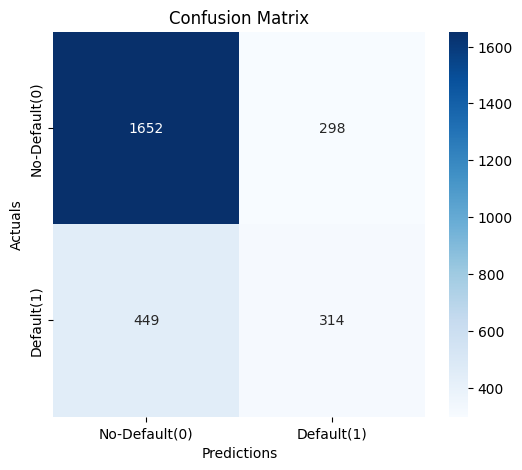

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['No-Default(0)', 'Default(1)'], yticklabels=['No-Default(0)', 'Default(1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predictions')
plt.ylabel('Actuals')
plt.show()

In [30]:
print('Classification report')
print(classification_report(y_test, predictions))

Classification report
              precision    recall  f1-score   support

           0       0.79      0.85      0.82      1950
           1       0.51      0.41      0.46       763

    accuracy                           0.72      2713
   macro avg       0.65      0.63      0.64      2713
weighted avg       0.71      0.72      0.71      2713



# **Conclusion**

The **XGBClassifier** was selected for predicting default risk due to its balanced performance across accuracy and F1 scores. However, the model's recall for detecting defaulters (class 1) was lower than desired, indicating a **trade-off** between **precision** and **recall**. The model missed a significant portion of actual defaulters (false negatives), which can result in **missed financial opportunities** to intervene with at-risk customers.

#### **Business Implications:**
- **Low Recall** for defaults means high-risk customers are not always flagged for intervention, which could lead to financial losses.
- **False Positives** (298 non-defaulters predicted as defaulters) suggest the need for balancing interventions and improving resource allocation.

This predictive model offers valuable insights into identifying high-risk customers and reducing loan defaults, providing actionable steps the car dealershop to improve their financial planning and risk management.